In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from tqdm import tqdm

In [3]:
input_root = "/content/drive/MyDrive/Flying object detection/UAV_Dataset"
output_root = "/content/drive/MyDrive/Flying object detection/Augmented"
os.makedirs(output_root, exist_ok=True)

In [4]:
def rotate_image(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    return cv2.warpAffine(img, M, (w, h))

def adjust_brightness(img, factor):
    pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    enhancer = ImageEnhance.Brightness(pil_img)
    enhanced_img = enhancer.enhance(factor)
    return cv2.cvtColor(np.array(enhanced_img), cv2.COLOR_RGB2BGR)

def add_noise(img):
    noise = np.random.normal(0, 25, img.shape).astype(np.uint8)
    return cv2.add(img, noise)

def show_augmented_images(folder, category, n=10):
    files = sorted([f for f in os.listdir(folder) if f.endswith(('.jpg', '.png', '.jpeg', '.bmp'))])[:n]
    plt.figure(figsize=(15, 6))
    for i, file in enumerate(files):
        img = cv2.imread(os.path.join(folder, file))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 5, i+1)
        plt.imshow(img_rgb)
        plt.title(file, fontsize=8)
        plt.axis("off")
    plt.suptitle(f"Приклади аугментованих зображень: {category}")
    plt.tight_layout()
    plt.show()

Аугментація: Aeroplane: 100%|██████████| 1015/1015 [03:05<00:00,  5.48it/s]


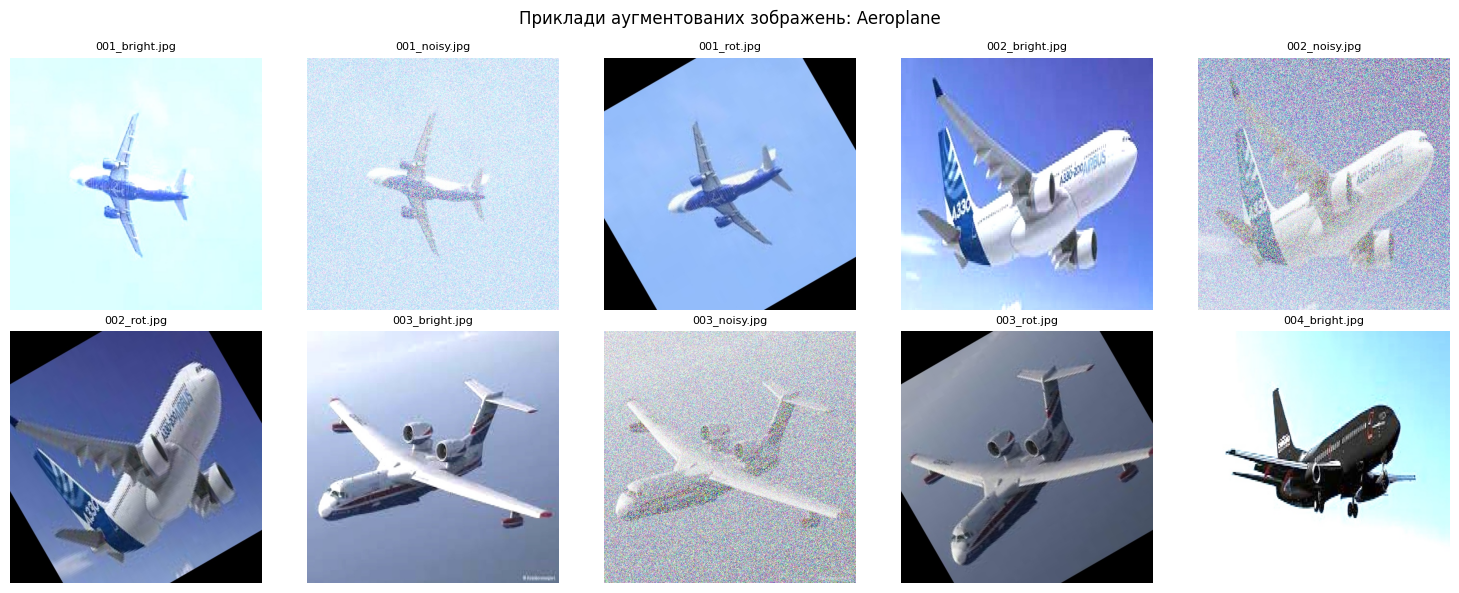

Аугментація: Drone: 100%|██████████| 1031/1031 [04:32<00:00,  3.79it/s]


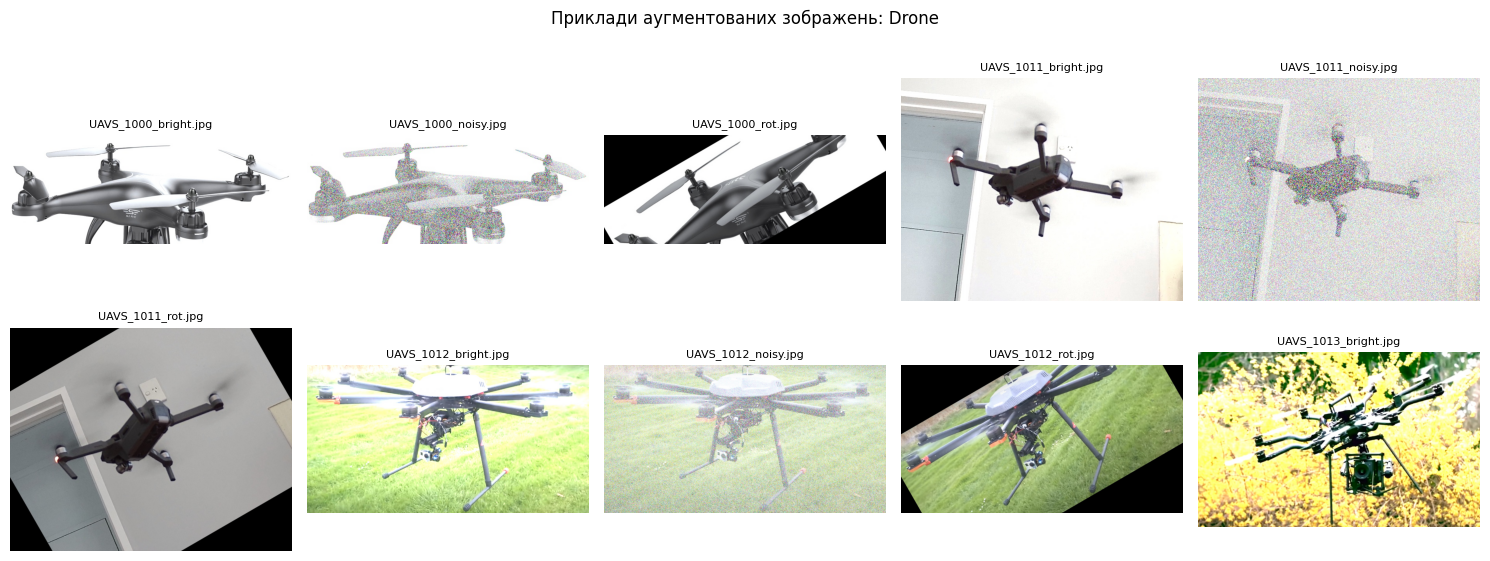

Аугментація: Helicopter: 100%|██████████| 1012/1012 [07:41<00:00,  2.19it/s]


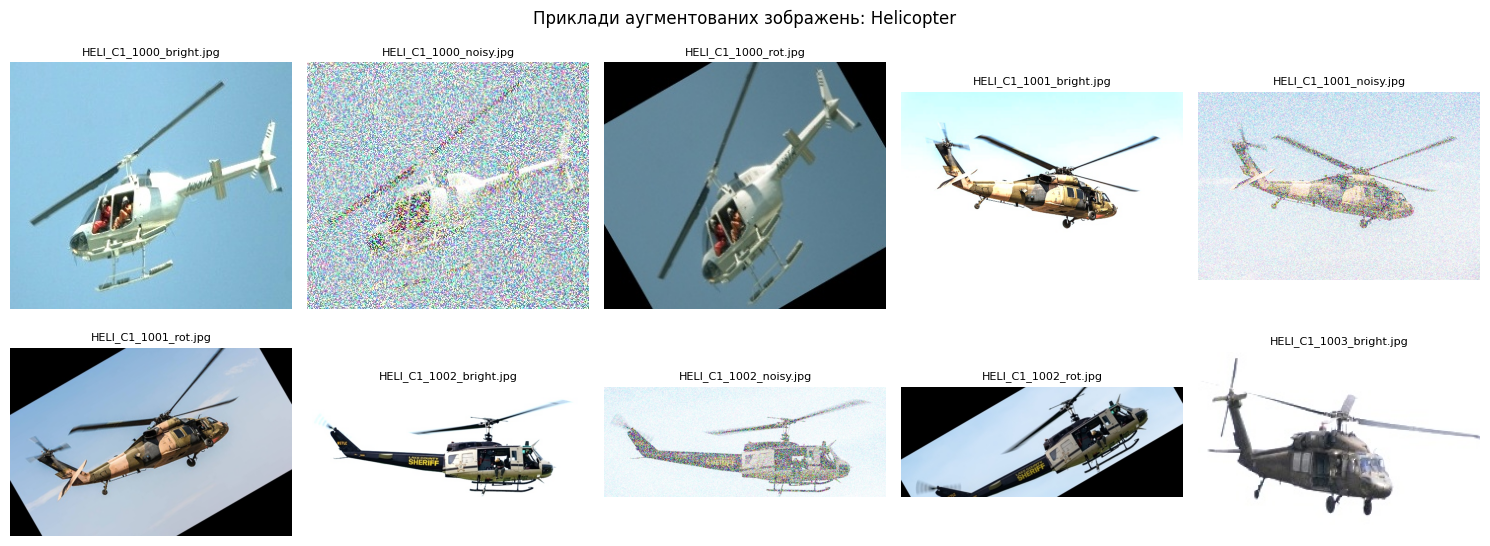

Аугментація: Bird: 100%|██████████| 1007/1007 [01:47<00:00,  9.36it/s]


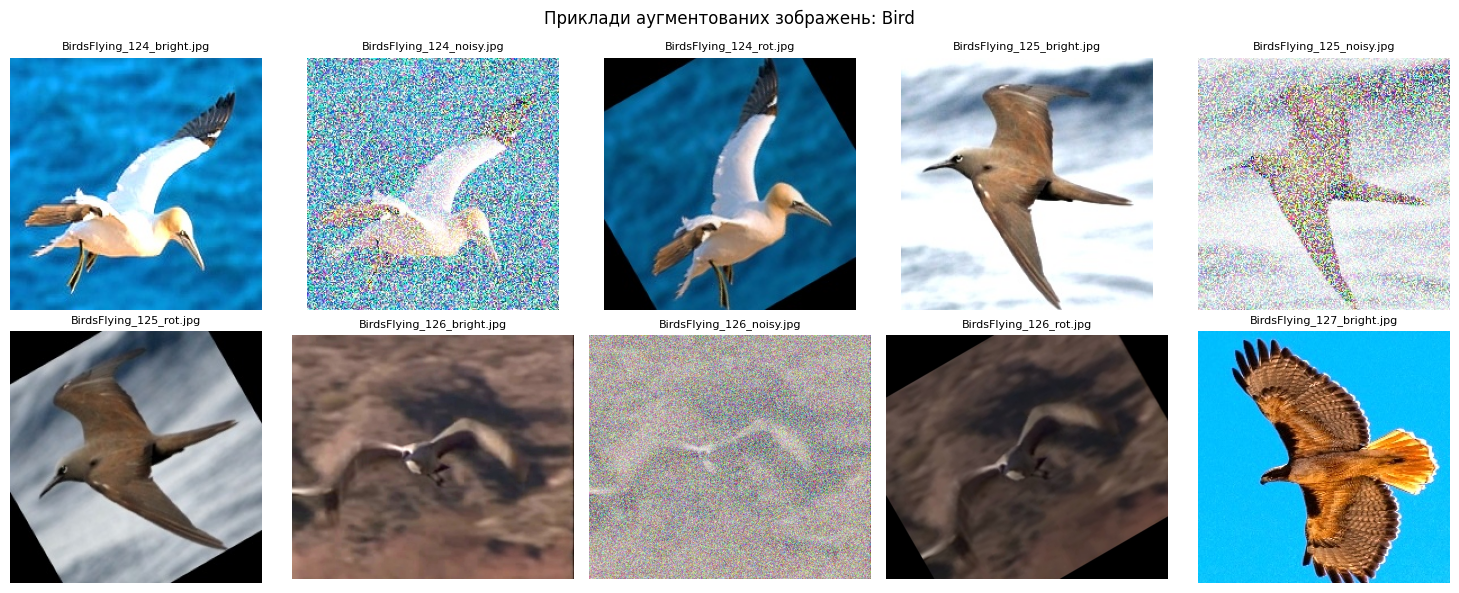

In [5]:
for category in os.listdir(input_root):
    category_path = os.path.join(input_root, category)
    if not os.path.isdir(category_path):
        continue

    output_category_path = os.path.join(output_root, category)
    os.makedirs(output_category_path, exist_ok=True)

    for filename in tqdm(os.listdir(category_path), desc=f"Аугментація: {category}"):
        if not filename.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp')):
            continue

        img_path = os.path.join(category_path, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue

        name, ext = os.path.splitext(filename)

        # Обертання
        rotated = rotate_image(img, 30)
        cv2.imwrite(os.path.join(output_category_path, f"{name}_rot{ext}"), rotated)

        # Яскравість
        bright = adjust_brightness(img, 1.5)
        cv2.imwrite(os.path.join(output_category_path, f"{name}_bright{ext}"), bright)

        # Шум
        noisy = add_noise(img)
        cv2.imwrite(os.path.join(output_category_path, f"{name}_noisy{ext}"), noisy)

    # Вивід прикладів
    show_augmented_images(output_category_path, category)